In [1]:
# !pip install --user pingouin

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import ast
import os
import ete3
import dendropy

from ete3 import Tree, TreeStyle, TextFace, add_face_to_node, PhyloTree
from IPython.display import display, HTML
from pingouin import ancova

# Fixes ete3 from killing the kernel in iPython
os.environ['QT_QPA_PLATFORM']='offscreen'

In [3]:
!mkdir -p ./newick_trees

In [4]:
species_dict = {"Bd": 'Brevundimonas_diminuta_HAMBI_18',
                "Ct": 'Comamonas_testosteroni_HAMBI_403',
                "Ec": 'Escherichia_coli_ATCC_11303',
                "Jl": 'Janthinobacterium_lividum_HAMBI_1919',
                "Sm": 'Serratia_marcescens_ATCC_13880',
                "Sc": 'Sphingomonas_capsulata_HAMBI_103',
                "Pf": 'Pseudomonas_fluorescens_SBW25'}

exp_dict = {"PS": "bacteria-ciliate",
            "NP": "bacteria_alone"}

replicates = ["PS_Bd_r01", "PS_Bd_r02", "PS_Bd_r03",
              "PS_Ct_r01", "PS_Ct_r02", "PS_Ct_r03",
              "PS_Pf_r01", "PS_Pf_r02", "PS_Pf_r03",
              "PS_Sc_r01", "PS_Sc_r02", "PS_Sc_r03",
              "PS_Sm_r01", "PS_Sm_r02", "PS_Sm_r03",
              "NP_Bd_r01", "NP_Bd_r02", "NP_Bd_r03",
              "NP_Ct_r01", "NP_Ct_r02", "NP_Ct_r03",
              "NP_Pf_r01", "NP_Pf_r02", "NP_Pf_r03",
              "NP_Sc_r01", "NP_Sc_r02", "NP_Sc_r03",
              "NP_Sm_r01", "NP_Sm_r02", "NP_Sm_r03"]

In [5]:
newick_tree_df = pd.DataFrame(columns=["Tree"], index=replicates)

newick_tree_df.loc["PS_Bd_r01"] = '((((A:27,(ADF:252,(ADG:168,AD:168):280):84):112,(ACE:505,AC:505):139):28,AB:140):28,0:140):84;'
newick_tree_df.loc["PS_Bd_r02"] = '(((A:140,((ACD:532,(ACDEG:84,ACDE:28):448):28,AC:28):112):28,(ABF:84,AB:336):364):0,0:56):84;'
newick_tree_df.loc["PS_Bd_r03"] = '(A:226,(B:280,((C:474,((CDE:168,CDEF:252):140,(CDG:112,CD:84):280):82):114,0:532):84):28):84;'
newick_tree_df.loc["PS_Ct_r01"] = '(A:588,(B:142,((C:56,CD:420):0,(E:308,(((F:84,FH:84):84,FG:140):140,0:308):84):56):168):0):168;'
newick_tree_df.loc["PS_Ct_r02"] = '(A:336,(((B:56,(BGH:252,BG:252):28):336,(BCD:476,BC:560):56):56,(E:224,(F:27,0:532):0):140):28):84;'
newick_tree_df.loc["PS_Ct_r03"] = '((((A:168,(ADE:168,((ADF:56,ADFG:56):28,AD:84):84):0):168,AC:168):336,AB:198):28,0:700):84;'
newick_tree_df.loc["PS_Pf_r01"] = '((A:364,AC:532):196,((B:474,(BDE:224,BD:224):250):142,0:616):112):56;'
newick_tree_df.loc["PS_Pf_r02"] = '(((A:28,(AEF:196,(AEG:56,AE:56):168):56):194,(ABD:259,AB:420):54):254,(C:446,0:446):254):56;'
newick_tree_df.loc["PS_Pf_r03"] = '(A:392,((B:364,BC:140):280,((D:168,(DFG:28,DF:28):140):140,(E:196,0:280):28):336):28):112;'
newick_tree_df.loc["PS_Sc_r01"] = '(((A:28,(ACD:84,(ACE:168,AC:224):56):84):56,(ABF:140,AB:112):308):112,0:28):224;'
newick_tree_df.loc["PS_Sc_r02"] = '(A:140,((B:56,(BCD:364,((BCE:84,BCEF:84):308,BC:84):0):56):84,0:27):56):196;'
newick_tree_df.loc["PS_Sc_r03"] = '(((A:168,(ADE:112,((ADF:28,ADFG:28):168,AD:28):196):56):140,(ABC:57,AB:281):83):0,0:140):196;'
newick_tree_df.loc["PS_Sm_r01"] = '(A:198,(((B:168,BE:168):476,(BCD:336,BC:336):308):0,0:644):56):91;'
newick_tree_df.loc["PS_Sm_r02"] = '(A:195,(((B:392,BD:336):28,((BCE:112,BCEF:112):0,BC:56):308):252,0:560):56):63;'
newick_tree_df.loc["PS_Sm_r03"] = '((A:502,AD:250):198,(((B:168,(BEF:168,BE:168):252):224,BC:224):56,0:700):0):91;'

newick_tree_df.loc["NP_Bd_r01"] = '(A:126,(B:490,(((C:57,(CEF:251,(CEG:111,CE:111):140):169):0,CD:197):0,0:420):98):28):146;'
newick_tree_df.loc["NP_Bd_r02"] = '(A:407,(B:651,((((C:132,CF:132):56,CE:188):56,CD:84):281,0:525):126):0):146;'
newick_tree_df.loc["NP_Bd_r03"] = '(A:651,(B:421,(C:525,(D:244,0:56):281):0):126):146;'
newick_tree_df.loc["NP_Ct_r01"] = '((((A:55,AG:76):168,((ACD:56,ACDF:188):56,(ACE:140,AC:28):28):0):224,AB:224):183,0:651):146;'
newick_tree_df.loc["NP_Ct_r02"] = '(((A:224,((ACD:224,(ACDEF:56,(ACDEG:244,((ACDEH:21,ACDEHI:21):167,ACDE:188):56):0):224):0,AC:468):0):155,AB:519):28,0:126):146;'
newick_tree_df.loc["NP_Ct_r03"] = '(((A:28,((((ACD:104,ACDH:104):56,ACDG:160):0,ACDF:160):84,(ACE:84,AC:112):0):0):407,AB:407):63,0:246):83;'
newick_tree_df.loc["NP_Pf_r01"] = '((A:251,AD:251):210,(B:154,(((C:139,(CFG:28,CF:21):111):28,CE:56):84,0:251):154):56):146;'
newick_tree_df.loc["NP_Pf_r02"] = '(((A:365,AE:525):0,AD:525):189,(((B:28,BF:412):141,BC:28):70,0:623):91):83;'
newick_tree_df.loc["NP_Pf_r03"] = '((A:540,(ABC:308,(ABD:391,(ABE:104,AB:104):308):0):204):125,0:441):56;'
newick_tree_df.loc["NP_Sc_r01"] = '(((A:56,AC:56):224,AB:280):57,((D:48,DF:48):112,(E:139,0:84):0):365):272;'
newick_tree_df.loc["NP_Sc_r02"] = '(A:84,((B:28,((((BCD:7,BCDG:7):21,BCDF:28):83,BCDE:83):28,BC:28):28):28,0:28):56):56;'
newick_tree_df.loc["NP_Sc_r03"] = '((A:281,((ABC:28,ABCD:56):224,AB:224):57):70,(E:28,((F:21,FG:21):111,0:28):28):435):202;'
newick_tree_df.loc["NP_Sm_r01"] = '((A:547,(((ABD:28,ABDF:28):140,ABDE:168):0,AB:28):407):63,(C:519,0:351):119):132;'
newick_tree_df.loc["NP_Sm_r02"] = '(((A:224,AE:392):155,(ACF:168,AC:168):379):91,((B:308,BD:308):162,0:470):0):132;'
newick_tree_df.loc["NP_Sm_r03"] = '(A:491,((B:140,(BCD:84,(BCE:140,BC:140):28):0):323,0:491):56):223;'


# for index in newick_tree_df.index:
#     f = open("newick_trees/" + index + ".nwt", 'w')
#     f.write(newick_tree_df.loc[index, "Tree"])
#     f.close()

# Tree renders

In [6]:
for replicate in replicates:
    tree = Tree(newick_tree_df.loc[replicate, "Tree"])
    ts = TreeStyle()
    
    ts.show_leaf_name = False
    ts.show_scale = False
    ts.show_branch_length = True
    ts.show_leaf_name = True
    tree.render("./newick_trees/ete3_renders/" + replicate + ".pdf", units="in", w=6, h=3, tree_style=ts)

QStandardPaths: XDG_RUNTIME_DIR not set, defaulting to '/run/nvme/job_32250260/tmp/runtime-kiciadov'


# Tree statistics

In [7]:
def leaf_depths(tree):
    depths = {}
    for x in ['0'] + re.findall(r'([a-zA-Z]+)', tree):
        l = tree.split(x + ":")[0]
        r = tree.split(x + ":")[1]
        assert np.abs(l.count("(") - l.count(")")) == np.abs(l.count(")") - l.count("("))
        depths[x] = np.abs(l.count("(") - l.count(")"))
    return depths

In [8]:
number_of_clusters = []
total_branch_lengths = []
branch_length_means = []
branch_length_variances = []
max_depths = []
average_depths = []
sackin_indices = []   # Sum of the depths of all leaves in the tree
colless_indices = []  # Sum of the absolute differences in the number of terminal nodes subtended by every bifurcation
b1_indices = []       # The inverse sum of all the longest paths to leaves for each node besides root
b2_indices = []       # Shannon entropy of the probability distrubtion of random walks to leaves from root
treenesses = []
nbars = []
for replicate in newick_tree_df.index:
    
    branch_lengths = np.array(re.findall(r':([0-9]+)', newick_tree_df.loc[replicate, "Tree"])).astype(int)
    depths = list(leaf_depths(newick_tree_df.loc[replicate, "Tree"]).values())
    total_branch_lengths.append(np.sum(branch_lengths))
    branch_length_means.append(np.mean(branch_lengths))
    branch_length_variances.append(np.var(branch_lengths))
    number_of_clusters.append(len(re.findall(r'[A-Z]+', newick_tree_df.loc[replicate, "Tree"])))
    max_depths.append(max(depths))
    average_depths.append(np.mean(depths))
    tree = dendropy.Tree.get(data=newick_tree_df.loc[replicate, "Tree"], schema="newick")
    sackin_indices.append(dendropy.calculate.treemeasure.sackin_index(tree, normalize=False))
    colless_indices.append(dendropy.calculate.treemeasure.colless_tree_imbalance(tree, normalize=False))
    b1_indices.append(dendropy.calculate.treemeasure.B1(tree))
    treenesses.append(dendropy.calculate.treemeasure.treeness(tree))
    nbars.append(dendropy.calculate.treemeasure.N_bar(tree))

newick_tree_stats_df = pd.DataFrame({"Species": [x.split("_")[1] for x in newick_tree_df.index],
                                     "Sum": total_branch_lengths,
                                     "Mean": branch_length_means,
                                     "Variance": branch_length_variances,
                                     "Clusters": number_of_clusters,
                                     "Max depth": max_depths,
                                     "Average depth": average_depths,
                                     "Sackin index": sackin_indices,
                                     "Colless index": colless_indices,
                                     "B1 index": b1_indices,
                                     "Treeness": treenesses,
                                     "Nbar": nbars}, index=newick_tree_df.index)

newick_tree_stats_df = pd.get_dummies(newick_tree_stats_df)
newick_tree_stats_df["Experiment"] = [x.split("_")[0] for x in newick_tree_df.index]
newick_tree_stats_df

,Sum,Mean,Variance,Clusters,Max depth,Average depth,Sackin index,Colless index,B1 index,Treeness,Nbar,Species_Bd,Species_Ct,Species_Pf,Species_Sc,Species_Sm,Experiment
PS_Bd_r01,2660,177.333333,21611.288889,7,6,4.000000,32.0,16.0,3.283333,0.260481,4.000000,True,False,False,False,False,PS
PS_Bd_r02,2352,156.800000,27994.026667,7,6,3.875000,31.0,15.0,3.283333,0.432099,3.875000,True,False,False,False,False,PS
PS_Bd_r03,2940,196.000000,20325.333333,7,6,4.250000,34.0,18.0,3.283333,0.254902,4.250000,True,False,False,False,False,PS
PS_Ct_r01,2830,166.470588,23004.013841,8,7,4.444444,40.0,22.0,3.450000,0.199850,4.444444,False,True,False,False,False,PS
PS_Ct_r02,3443,202.529412,33366.366782,8,5,3.777778,34.0,12.0,4.583333,0.191724,3.777778,False,True,False,False,False,PS
PS_Ct_r03,2326,155.066667,28221.262222,7,7,4.375000,35.0,21.0,2.450000,0.287244,4.375000,False,True,False,False,False,PS
PS_Pf_r01,3190,290.000000,30151.272727,5,4,2.833333,17.0,5.0,2.833333,0.223357,2.833333,False,False,True,False,False,PS
PS_Pf_r02,2943,196.200000,20896.560000,7,5,3.375000,27.0,9.0,4.083333,0.339453,3.375000,False,False,True,False,False,PS
PS_Pf_r03,2660,177.333333,15017.955556,7,5,3.625000,29.0,11.0,4.083333,0.373626,3.625000,False,False,True,False,False,PS
PS_Sc_r01,1624,124.923077,6708.071006,6,5,3.428571,24.0,10.0,3.083333,0.440000,3.428571,False,False,False,True,False,PS


In [9]:
# RUI indices from R
ruiindices = pd.read_csv("tree_RUIindices.csv", index_col=1)
ruiindices = ruiindices.iloc[:, 1:]
newick_tree_stats_df = pd.concat([newick_tree_stats_df, ruiindices], axis=1)
newick_tree_stats_df = newick_tree_stats_df.loc[:, ["Sum", "Mean", "Variance", "Clusters", "Max depth", "Average depth", "Sackin index", "Colless index", "B1 index", "Treeness", "Nbar", "D0N", "D1N", "J1N", "D0S", "D1S", "J1S", "D0L", "D1L", "J1L", "Species_Bd", "Species_Ct", "Species_Pf", "Species_Sc", "Species_Sm", "Experiment"]]

In [10]:
stat_names = ["Sum", "Mean", "Variance", "Clusters", "Max depth", "Average depth", "Sackin index", "Colless index", "B1 index", "Treeness", "Nbar", "D0N", "D1N", "J1N", "D0S", "D1S", "J1S", "D0L", "D1L", "J1L"]
for stat in stat_names:
    pval = np.round(ancova(data=newick_tree_stats_df, dv=stat, between="Experiment", covar=["Species_Bd", "Species_Ct", "Species_Pf", "Species_Sc", "Species_Sm"])["p-unc"].values[0], 3)
    if pval <= 0.05:
        pval = str(pval) + "**"
    elif pval <= 0.1:
        pval = str(pval) + "*"
    if stat in ["Sum", "Mean"]:
        print(stat + "\t\t" + str(pval))
    else:
        print(stat + "\t" + str(pval))

Sum		0.053*
Mean		0.431
Variance	0.901
Clusters	0.528
Max depth	0.759
Average depth	0.754
Sackin index	0.752
Colless index	0.928
B1 index	0.285
Treeness	0.798
Nbar	0.754
D0N	0.201
D1N	0.609
J1N	0.179
D0S	0.134
D1S	0.059*
J1S	0.168
D0L	0.645
D1L	0.48
J1L	0.206


In [11]:
from scipy.stats import f_oneway

species_names = ["Bd", "Ct", "Pf", "Sc", "Sm"]
stat_names = ["Sum", "Mean", "Variance", "Clusters", "Max depth", "Average depth", "Sackin index", "Colless index", "B1 index", "Treeness", "Nbar", "D0N", "D1N", "J1N", "D0S", "D1S", "J1S", "D0L", "D1L", "J1L"]
anova_stats_df = pd.DataFrame(index=species_names, columns=stat_names)
for stat in stat_names:
    for species in species_names:
        res = f_oneway(newick_tree_stats_df[(newick_tree_stats_df["Experiment"] == "PS") & (newick_tree_stats_df["Species_" + species] == True)][stat], newick_tree_stats_df[(newick_tree_stats_df["Experiment"] == "NP") & (newick_tree_stats_df["Species_" + species] == True)][stat])
        pval = np.round(res[1], 3)
        print(res)
        if pval <= 0.05:
            pval = str(pval) + "**"
        elif pval <= 0.1:
            pval = str(pval) + "*"
        anova_stats_df.loc[species, stat] = pval
anova_stats_df

F_onewayResult(statistic=0.33487191764424223, pvalue=0.5938253656556771)
F_onewayResult(statistic=1.3734297370719328, pvalue=0.30626212182551893)
F_onewayResult(statistic=1.1932613332885431, pvalue=0.33605308661893196)
F_onewayResult(statistic=0.3405729648554933, pvalue=0.5908213190225355)
F_onewayResult(statistic=0.5660968974953094, pvalue=0.4936684498934937)
F_onewayResult(statistic=1.1264268645522346, pvalue=0.348369830368313)
F_onewayResult(statistic=4.07683843611567, pvalue=0.1136118273950445)
F_onewayResult(statistic=0.1762823116385352, pvalue=0.6961587498877576)
F_onewayResult(statistic=0.46628716652541036, pvalue=0.532198344806557)
F_onewayResult(statistic=0.8338076350194467, pvalue=0.4128330012273278)
F_onewayResult(statistic=1.4182657790063355, pvalue=0.2995280572168263)
F_onewayResult(statistic=4.685486348702836, pvalue=0.09639126768095456)
F_onewayResult(statistic=0.14068340695928017, pvalue=0.7266430584085134)
F_onewayResult(statistic=0.06469551959857317, pvalue=0.81176339

,Sum,Mean,Variance,Clusters,Max depth,Average depth,Sackin index,Colless index,B1 index,Treeness,Nbar,D0N,D1N,J1N,D0S,D1S,J1S,D0L,D1L,J1L
Bd,0.594,0.348,0.3,0.205,0.725,0.487,0.321,0.628,0.004**,0.099*,0.487,0.054*,0.008**,0.644,0.298,0.189,0.379,0.595,0.416,0.639
Ct,0.306,0.114,0.096*,0.643,0.643,0.448,0.458,0.485,0.921,0.228,0.448,0.498,0.344,0.194,0.793,0.47,0.292,0.288,0.245,0.182
Pf,0.336,0.696,0.727,0.725,0.643,0.807,0.898,0.693,0.259,0.497,0.807,0.777,0.806,0.912,0.574,0.557,0.661,0.577,0.823,0.938
Sc,0.591,0.532,0.812,0.519,0.468,0.661,0.948,0.575,0.433,0.07*,0.661,0.186,0.338,0.622,0.47,0.369,0.586,0.554,0.741,0.658
Sm,0.494,0.413,0.492,1.0,0.678,0.398,0.547,0.51,0.926,0.749,0.398,0.137,0.586,0.891,0.786,0.787,0.499,0.767,0.931,0.867


# Clone survival

In [12]:
# Added root to each tree to facilitate clone survival calculation
newick_tree_df_2 = pd.DataFrame(columns=["Tree"], index=replicates)

newick_tree_df_2.loc["PS_Bd_r01"] = '(((((A:27,(ADF:252,(ADG:168,AD:168):280):84):112,(ACE:505,AC:505):139):28,AB:140):28,0:140):84);'
newick_tree_df_2.loc["PS_Bd_r02"] = '((((A:140,((ACD:532,(ACDEG:84,ACDE:28):448):28,AC:28):112):28,(ABF:84,AB:336):364):0,0:56):84);'
newick_tree_df_2.loc["PS_Bd_r03"] = '((A:226,(B:280,((C:474,((CDE:168,CDEF:252):140,(CDG:112,CD:84):280):82):114,0:532):84):28):84);'
newick_tree_df_2.loc["PS_Ct_r01"] = '((A:588,(B:142,((C:56,CD:420):0,(E:308,(((F:84,FH:84):84,FG:140):140,0:308):84):56):168):0):168);'
newick_tree_df_2.loc["PS_Ct_r02"] = '((A:336,(((B:56,(BGH:252,BG:252):28):336,(BCD:476,BC:560):56):56,(E:224,(F:27,0:532):0):140):28):84);'
newick_tree_df_2.loc["PS_Ct_r03"] = '(((((A:168,(ADE:168,((ADF:56,ADFG:56):28,AD:84):84):0):168,AC:168):336,AB:198):28,0:700):84);'
newick_tree_df_2.loc["PS_Pf_r01"] = '(((A:364,AC:532):196,((B:474,(BDE:224,BD:224):250):142,0:616):112):56);'
newick_tree_df_2.loc["PS_Pf_r02"] = '((((A:28,(AEF:196,(AEG:56,AE:56):168):56):194,(ABD:259,AB:420):54):254,(C:446,0:446):254):56);'
newick_tree_df_2.loc["PS_Pf_r03"] = '((A:392,((B:364,BC:140):280,((D:168,(DFG:28,DF:28):140):140,(E:196,0:280):28):336):28):112);'
newick_tree_df_2.loc["PS_Sc_r01"] = '((((A:28,(ACD:84,(ACE:168,AC:224):56):84):56,(ABF:140,AB:112):308):112,0:28):224);'
newick_tree_df_2.loc["PS_Sc_r02"] = '((A:140,((B:56,(BCD:364,((BCE:84,BCEF:84):308,BC:84):0):56):84,0:27):56):196);'
newick_tree_df_2.loc["PS_Sc_r03"] = '((((A:168,(ADE:112,((ADF:28,ADFG:28):168,AD:28):196):56):140,(ABC:57,AB:281):83):0,0:140):196);'
newick_tree_df_2.loc["PS_Sm_r01"] = '((A:198,(((B:168,BE:168):476,(BCD:336,BC:336):308):0,0:644):56):91);'
newick_tree_df_2.loc["PS_Sm_r02"] = '((A:195,(((B:392,BD:336):28,((BCE:112,BCEF:112):0,BC:56):308):252,0:560):56):63);'
newick_tree_df_2.loc["PS_Sm_r03"] = '(((A:502,AD:250):198,(((B:168,(BEF:168,BE:168):252):224,BC:224):56,0:700):0):91);'

newick_tree_df_2.loc["NP_Bd_r01"] = '((A:126,(B:490,(((C:57,(CEF:251,(CEG:111,CE:111):140):169):0,CD:197):0,0:420):98):28):146);'
newick_tree_df_2.loc["NP_Bd_r02"] = '((A:407,(B:651,((((C:132,CF:132):56,CE:188):56,CD:84):281,0:525):126):0):146);'
newick_tree_df_2.loc["NP_Bd_r03"] = '((A:651,(B:421,(C:525,(D:244,0:56):281):0):126):146);'
newick_tree_df_2.loc["NP_Ct_r01"] = '(((((A:55,AG:76):168,((ACD:56,ACDF:188):56,(ACE:140,AC:28):28):0):224,AB:224):183,0:651):146);'
newick_tree_df_2.loc["NP_Ct_r02"] = '((((A:224,((ACD:224,(ACDEF:56,(ACDEG:244,((ACDEH:21,ACDEHI:21):167,ACDE:188):56):0):224):0,AC:468):0):155,AB:519):28,0:126):146);'
newick_tree_df_2.loc["NP_Ct_r03"] = '((((A:28,((((ACD:104,ACDH:104):56,ACDG:160):0,ACDF:160):84,(ACE:84,AC:112):0):0):407,AB:407):63,0:246):83);'
newick_tree_df_2.loc["NP_Pf_r01"] = '(((A:251,AD:251):210,(B:154,(((C:139,(CFG:28,CF:21):111):28,CE:56):84,0:251):154):56):146);'
newick_tree_df_2.loc["NP_Pf_r02"] = '((((A:365,AE:525):0,AD:525):189,(((B:28,BF:412):141,BC:28):70,0:623):91):83);'
newick_tree_df_2.loc["NP_Pf_r03"] = '(((A:540,(ABC:308,(ABD:391,(ABE:104,AB:104):308):0):204):125,0:441):56);'
newick_tree_df_2.loc["NP_Sc_r01"] = '((((A:56,AC:56):224,AB:280):57,((D:48,DF:48):112,(E:139,0:84):0):365):272);'
newick_tree_df_2.loc["NP_Sc_r02"] = '((A:84,((B:28,((((BCD:7,BCDG:7):21,BCDF:28):83,BCDE:83):28,BC:28):28):28,0:28):56):56);'
newick_tree_df_2.loc["NP_Sc_r03"] = '(((A:281,((ABC:28,ABCD:56):224,AB:224):57):70,(E:28,((F:21,FG:21):111,0:28):28):435):202);'
newick_tree_df_2.loc["NP_Sm_r01"] = '(((A:547,(((ABD:28,ABDF:28):140,ABDE:168):0,AB:28):407):63,(C:519,0:351):119):132);'
newick_tree_df_2.loc["NP_Sm_r02"] = '((((A:224,AE:392):155,(ACF:168,AC:168):379):91,((B:308,BD:308):162,0:470):0):132);'
newick_tree_df_2.loc["NP_Sm_r03"] = '((A:491,((B:140,(BCD:84,(BCE:140,BC:140):28):0):323,0:491):56):223);'

In [13]:
num_clones_survived = pd.read_csv("num_clones_survived.csv", index_col=0)
ref_times = pd.read_csv("rep_time.tsv", sep="\t", index_col=0)
clone_times_df = pd.DataFrame(index=replicates, columns=["Days", "Appearance", "Death"])
for replicate in replicates:
    tree = dendropy.Tree.get(data=newick_tree_df_2.loc[replicate, "Tree"], schema="newick")

    clone_times_df.loc[replicate, "Days"] = ref_times.loc[replicate, "Days"]
    clone_times_df.loc[replicate, "Appearance"] = sorted(list(age for (node, age) in tree.resolve_node_depths().items() if node.is_internal()))
    clone_times_df.loc[replicate, "Death"] = sorted(tree.calc_node_root_distances(return_leaf_distances_only=True))

In [14]:
exp_color_dict = {"PS": "tab:orange", "NP": "tab:blue"}
total_clone_numbers_df = pd.DataFrame(index=replicates, columns=["Treatment", "Days", "Clones"])
living_clone_numbers_df = pd.DataFrame(index=replicates, columns=["Treatment", "Days", "Clones"])

for replicate in replicates:
    days = ast.literal_eval(clone_times_df.loc[replicate, "Days"])
    appearance_times = [x for x in list(clone_times_df.loc[replicate, "Appearance"]) if x in days]
    death_times = list(clone_times_df.loc[replicate, "Death"])
    num_survived = num_clones_survived.loc[replicate, "Survived"]
    zdt = num_clones_survived.loc[replicate, "Zero death day"]
    
    x = []
    curr_count = 0
    for day in days:
        curr_count += len(np.where(np.array(appearance_times) == day)[0])
        x.append(curr_count)
    
    x_dict = {days[i]: x[i] for i in range(len(x))}

    total_clone_numbers_df.loc[replicate, "Treatment"] = replicate.split("_")[0]
    total_clone_numbers_df.loc[replicate, "Days"] = list(x_dict.keys())
    total_clone_numbers_df.loc[replicate, "Clones"] = list(x_dict.values())

    curr_dead_count = 0
    for day in days[:-1]:
        curr_dead_count += len(np.where(np.array(death_times) == day)[0])
        if day == zdt:
            curr_dead_count -= 1
            
        x_dict[day] -= curr_dead_count
    
    if pd.isna(zdt):
        x_dict[days[-1]] = num_survived - 1
    else:
        x_dict[days[-1]] = num_survived    
    
    living_clone_numbers_df.loc[replicate, "Treatment"] = replicate.split("_")[0]
    living_clone_numbers_df.loc[replicate, "Days"] = list(x_dict.keys())
    living_clone_numbers_df.loc[replicate, "Clones"] = list(x_dict.values())

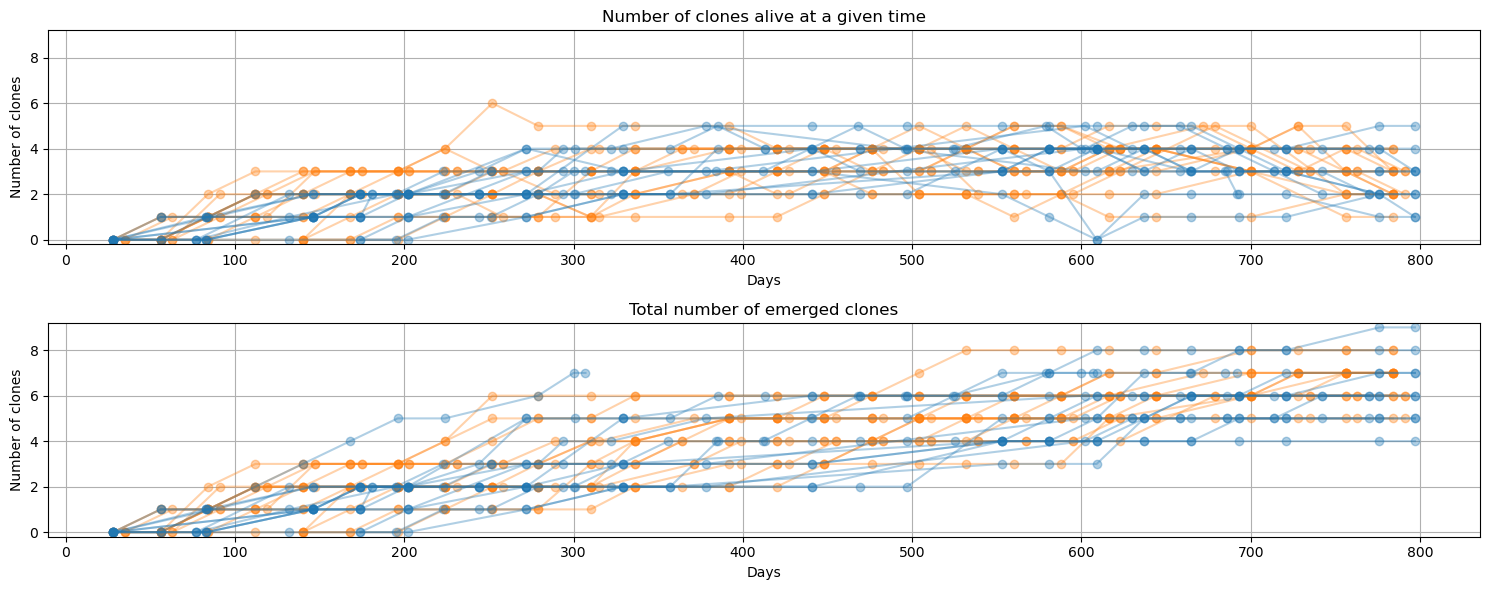

In [15]:
plt.subplots(2, 1, figsize=(15, 6))
plt.subplot(211)
for replicate in replicates:
    plt.plot(living_clone_numbers_df.loc[replicate, "Days"], living_clone_numbers_df.loc[replicate, "Clones"], marker="o", alpha=0.35, color=exp_color_dict[living_clone_numbers_df.loc[replicate, "Treatment"]])

plt.ylim(-0.2, 9.2)
plt.title("Number of clones alive at a given time")
plt.xlabel("Days")
plt.ylabel("Number of clones")
plt.grid()

plt.subplot(212)
for replicate in replicates:
    plt.plot(total_clone_numbers_df.loc[replicate, "Days"], total_clone_numbers_df.loc[replicate, "Clones"], marker="o", alpha=0.35, color=exp_color_dict[total_clone_numbers_df.loc[replicate, "Treatment"]])
plt.ylim(-0.2, 9.2)
plt.title("Total number of emerged clones")
plt.grid()
plt.xlabel("Days")
plt.ylabel("Number of clones")
plt.tight_layout()
# plt.savefig("clone_accumulation_and_survival.png", dpi=200)
plt.show()

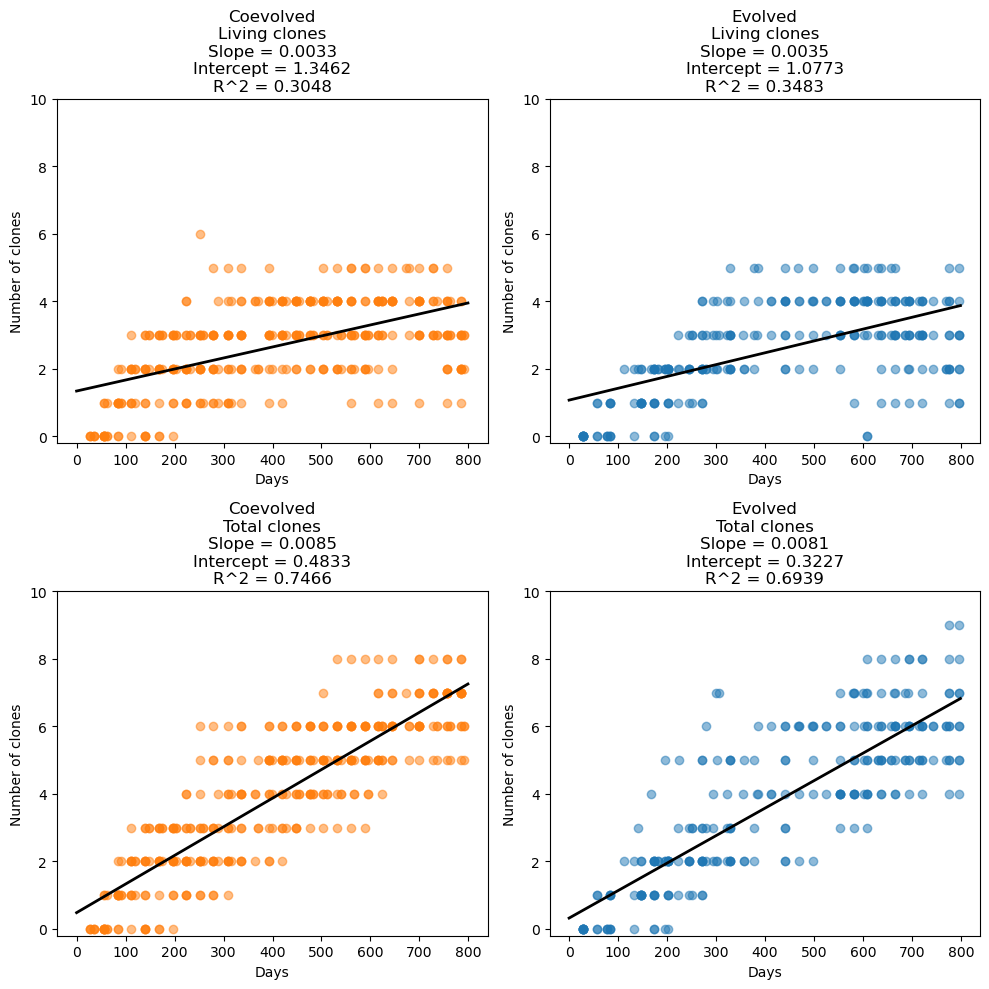

In [16]:
from scipy.stats import linregress

plt.subplots(2, 2, figsize=(10, 10))
plt.subplot(221)
df = living_clone_numbers_df
x = []
y = []
for replicate in df[df["Treatment"] == "PS"].index:
    x += list(df.loc[replicate, "Days"])
    y += list(df.loc[replicate, "Clones"])

lr = linregress(x, y)
x_lr = np.arange(0, 800, 1)
y_lr = x_lr*lr[0] + lr[1]
plt.scatter(x, y, color=exp_color_dict["PS"], alpha=0.5)
plt.plot(x_lr, y_lr, color="k", lw=2)
plt.ylim(-0.2, 10)
plt.xlabel("Days")
plt.ylabel("Number of clones")
plt.title("Coevolved\nLiving clones\nSlope = " + str(np.round(lr[0], 4)) + "\nIntercept = " + str(np.round(lr[1], 4)) + "\nR^2 = " + str(np.round(lr[2]**2, 4)))

plt.subplot(222)
df = living_clone_numbers_df
x = []
y = []
for replicate in df[df["Treatment"] == "NP"].index:
    x += list(df.loc[replicate, "Days"])
    y += list(df.loc[replicate, "Clones"])

lr = linregress(x, y)
x_lr = np.arange(0, 800, 1)
y_lr = x_lr*lr[0] + lr[1]
plt.scatter(x, y, color=exp_color_dict["NP"], alpha=0.5)
plt.plot(x_lr, y_lr, color="k", lw=2)
plt.ylim(-0.2, 10)
plt.xlabel("Days")
plt.ylabel("Number of clones")
plt.title("Evolved\nLiving clones\nSlope = " + str(np.round(lr[0], 4)) + "\nIntercept = " + str(np.round(lr[1], 4)) + "\nR^2 = " + str(np.round(lr[2]**2, 4)))

plt.subplot(223)
df = total_clone_numbers_df
x = []
y = []
for replicate in df[df["Treatment"] == "PS"].index:
    x += list(df.loc[replicate, "Days"])
    y += list(df.loc[replicate, "Clones"])

lr = linregress(x, y)
x_lr = np.arange(0, 800, 1)
y_lr = x_lr*lr[0] + lr[1]
plt.scatter(x, y, color=exp_color_dict["PS"], alpha=0.5)
plt.plot(x_lr, y_lr, color="k", lw=2)
plt.ylim(-0.2, 10)
plt.xlabel("Days")
plt.ylabel("Number of clones")
plt.title("Coevolved\nTotal clones\nSlope = " + str(np.round(lr[0], 4)) + "\nIntercept = " + str(np.round(lr[1], 4)) + "\nR^2 = " + str(np.round(lr[2]**2, 4)))

plt.subplot(224)
df = total_clone_numbers_df
x = []
y = []
for replicate in df[df["Treatment"] == "NP"].index:
    x += list(df.loc[replicate, "Days"])
    y += list(df.loc[replicate, "Clones"])

lr = linregress(x, y)
x_lr = np.arange(0, 800, 1)
y_lr = x_lr*lr[0] + lr[1]
plt.scatter(x, y, color=exp_color_dict["NP"], alpha=0.5)
plt.plot(x_lr, y_lr, color="k", lw=2)
plt.ylim(-0.2, 10)
plt.xlabel("Days")
plt.ylabel("Number of clones")
plt.title("Evolved\nTotal clones\nSlope = " + str(np.round(lr[0], 4)) + "\nIntercept = " + str(np.round(lr[1], 4)) + "\nR^2 = " + str(np.round(lr[2]**2, 4)))
plt.tight_layout()
# plt.savefig("clone_number_lr.png", dpi=200)
plt.show()